In [5]:
import os
import pandas as pd
import nibabel as nib
from nilearn.image import resample_img
from nilearn.glm.first_level import FirstLevelModel
from nilearn import datasets
import numpy as np

# 1. Rutas del proyecto
dataset_path = "C:/Users/Jewel/Desktop/Desktop TFM/mi-proyecto-datalad/ds001796"
output_dir = "C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker/"
subject_ids = ["sub-201", "sub-202", "sub-203", "sub-204", "sub-205", "sub-207", "sub-209"]
task_name = "flanker"
tr = 2.0

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Carga un template MNI para la normalización
mni_template = datasets.load_mni152_template()

# 2. Bucle para procesar cada sujeto
for subject_id in subject_ids:
    print(f"--- Procesando los datos del sujeto: {subject_id} ---")
    
    func_path = os.path.join(dataset_path, subject_id, "func", f"{subject_id}_task-{task_name}_bold.nii.gz")
    events_path = os.path.join(dataset_path, subject_id, "func", f"{subject_id}_task-{task_name}_events.tsv")

    try:
        func_img = nib.load(func_path)
        events = pd.read_csv(events_path, sep='\t')

        fmri_glm = FirstLevelModel(t_r=tr, noise_model='ar1', standardize=True)
        fmri_glm.fit(func_img, events=events)
        
        design_matrix = fmri_glm.design_matrices_[0]
        event_names = [col for col in design_matrix.columns if not col.startswith(('spikes', 'R', 'constant'))]
        if not event_names:
            print(f"Advertencia: No se encontraron eventos para {subject_id}. Saltando.")
            continue
            
        main_contrast_name = event_names[0]
        contrast_vector = np.zeros(design_matrix.shape[1])
        contrast_vector[design_matrix.columns.get_loc(main_contrast_name)] = 1
        
        z_map = fmri_glm.compute_contrast(contrast_vector, output_type='z_score')
        
        # Paso clave: Normalizar el mapa al template MNI
        z_map_normalized = resample_img(z_map, target_affine=mni_template.affine, target_shape=mni_template.shape)
        
        # Guarda el mapa Z normalizado en la carpeta de resultados
        z_map_normalized.to_filename(os.path.join(output_dir, f'z_map_{subject_id}.nii.gz'))
        print(f"Mapa Z normalizado para {subject_id} guardado en: {output_dir}")

    except FileNotFoundError as e:
        print(f"Error: No se encontró el archivo para {subject_id}: {e}")
    except Exception as e:
        print(f"Ocurrió un error en el análisis de {subject_id}: {e}")

--- Procesando los datos del sujeto: sub-201 ---
Error: No se encontró el archivo para sub-201: No such file or no access: 'C:/Users/Jewel/Desktop/Desktop TFM/mi-proyecto-datalad/ds001796/sub-201/func/sub-201_task-flanker_bold.nii.gz'
--- Procesando los datos del sujeto: sub-202 ---
Error: No se encontró el archivo para sub-202: No such file or no access: 'C:/Users/Jewel/Desktop/Desktop TFM/mi-proyecto-datalad/ds001796/sub-202/func/sub-202_task-flanker_bold.nii.gz'
--- Procesando los datos del sujeto: sub-203 ---
Error: No se encontró el archivo para sub-203: No such file or no access: 'C:/Users/Jewel/Desktop/Desktop TFM/mi-proyecto-datalad/ds001796/sub-203/func/sub-203_task-flanker_bold.nii.gz'
--- Procesando los datos del sujeto: sub-204 ---
Error: No se encontró el archivo para sub-204: No such file or no access: 'C:/Users/Jewel/Desktop/Desktop TFM/mi-proyecto-datalad/ds001796/sub-204/func/sub-204_task-flanker_bold.nii.gz'
--- Procesando los datos del sujeto: sub-205 ---
Error: No s

In [6]:
import os
import glob
import pandas as pd
from nilearn.glm.second_level import SecondLevelModel
from nilearn import plotting
import matplotlib.pyplot as plt # Importar matplotlib

# ----------------------------------------------------
# 1. Rutas a los mapas de activación
# ----------------------------------------------------
# Ruta a la carpeta donde has guardado tus mapas de activación individuales
output_dir = "C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker/" 

# Define la lista de los IDs de los sujetos que quieres incluir en el análisis de grupo
subject_ids_for_group = [
    "sub-201", "sub-202", "sub-203", "sub-204", 
    "sub-205", "sub-207", "sub-209"
]

# Construye una lista con las rutas completas a los archivos .nii.gz de estos sujetos
z_map_files = []
for subject_id in subject_ids_for_group:
    file_path = os.path.join(output_dir, f'z_map_{subject_id}.nii.gz')
    if os.path.exists(file_path):
        z_map_files.append(file_path)
    else:
        print(f"Advertencia: No se encontró el archivo {file_path}. Asegúrate de que los mapas de activación están guardados correctamente.")

if not z_map_files:
    print("Error: No se encontraron mapas de activación para los sujetos especificados. Abortando el análisis de grupo.")
    exit()

In [12]:
import os
import glob
import pandas as pd
from nilearn.glm.second_level import SecondLevelModel
from nilearn import plotting
import matplotlib.pyplot as plt # Importar matplotlib

# ----------------------------------------------------
# 1. Rutas a los mapas de activación
# ----------------------------------------------------
# Ruta a la carpeta donde has guardado tus mapas de activación individuales
output_dir = "C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker/" 

# Define la lista de los IDs de los sujetos que quieres incluir en el análisis de grupo
subject_ids_for_group = [
    "sub-201", "sub-202", "sub-203", "sub-204", 
    "sub-205", "sub-207", "sub-209"
]

# Construye una lista con las rutas completas a los archivos .nii.gz de estos sujetos
z_map_files = []
for subject_id in subject_ids_for_group:
    file_path = os.path.join(output_dir, f'z_map_{subject_id}.nii.gz')
    if os.path.exists(file_path):
        z_map_files.append(file_path)
    else:
        print(f"Advertencia: No se encontró el archivo {file_path}. Asegúrate de que los mapas de activación están guardados correctamente.")

if not z_map_files:
    print("Error: No se encontraron mapas de activación para los sujetos especificados. Abortando el análisis de grupo.")
    exit()

print(f"Se encontraron {len(z_map_files)} mapas Z individuales para el análisis de grupo.")



# ----------------------------------------------------
# 2. Análisis de Segundo Nivel (Análisis de Grupo)
# ----------------------------------------------------
print("--- Realizando el análisis de segundo nivel (grupo) ---")

# Crea una matriz de diseño simple para un t-test de una muestra
# Esto indica que hay un intercepto (media) para todos los sujetos
second_level_design_matrix = pd.DataFrame(
    [1] * len(z_map_files),  # Una columna de unos, un '1' por cada sujeto
    columns=['intercept']    # Nombra la columna como 'intercept'
)

second_level_model = SecondLevelModel(smoothing_fwhm=8) # Puedes ajustar el suavizado (FWHM)

# Ajusta el modelo a los mapas Z individuales, pasando la nueva design_matrix
second_level_model.fit(z_map_files, design_matrix=second_level_design_matrix)





# Calcula el contraste (por defecto, un t-test de una muestra sobre el 'intercept')
# Esto generará un mapa de activación a nivel de grupo.
group_map = second_level_model.compute_contrast('intercept', output_type='z_score') # Aquí se corrige






# ----------------------------------------------------
# 3. Guardar el mapa de activación de grupo
# ----------------------------------------------------
group_map_filename = os.path.join(output_dir, 'group_z_map.nii.gz')
group_map.to_filename(group_map_filename)
print(f"Mapa Z de activación de grupo guardado en: {group_map_filename}")

# ----------------------------------------------------
# 4. Visualizar y guardar el resultado
# ----------------------------------------------------
print("--- Visualizando el mapa de activación de grupo ---")

# Carga un atlas de coordenadas para etiquetar las regiones (opcional, pero útil)
# from nilearn import regions
# atlas_aal = datasets.fetch_atlas_aal() # Por ejemplo, un atlas AAL
# atlas_coords = plotting.find_cut_coords(group_map) # Busca coordenadas de los picos de activación

# Puedes ajustar el umbral (threshold) para la visualización
threshold_value = 3.1 # Z > 3.1 corresponde a p < 0.001 (no corregido)

# Crea la figura para la visualización
fig = plt.figure(figsize=(10, 8))
plotting.plot_stat_map(
    group_map, 
    bg_img=plotting.load_mni152_template(), # Fondo: cerebro MNI
    threshold=threshold_value,             # Umbral de activación
    display_mode='ortho',                  # Vistas ortogonales (sagital, coronal, axial)
    cut_coords=None,                       # Coordenadas de corte (None para automático)
    title='Activación de Grupo (Contraste Flanker)',
    cmap='cold_hot',                       # Mapa de color
    output_file=os.path.join(output_dir, 'group_activation_map.png'), # Guarda como PNG
    figure=fig
)

# Añade una barra de color
# plotting.show() # No se necesita con output_file

print(f"Imagen de activación de grupo guardada en: {os.path.join(output_dir, 'group_activation_map.png')}")

# Para que la imagen se muestre si no la guardas o si quieres verla después de guardar
# plt.show()

Se encontraron 7 mapas Z individuales para el análisis de grupo.
--- Realizando el análisis de segundo nivel (grupo) ---


ValueError: Field of view of image #1 is different from reference FOV.
Reference affine:
array([[   1.,    0.,    0.,  -98.],
       [   0.,    1.,    0., -134.],
       [   0.,    0.,    1.,  -72.],
       [   0.,    0.,    0.,    1.]])
Image affine:
array([[-2.11720538e+00,  2.15804502e-01,  1.38995469e-01,
         8.77073212e+01],
       [ 2.39691257e-01,  2.08365083e+00,  3.65575910e-01,
        -1.06570000e+02],
       [ 1.05362527e-01, -4.03657645e-01,  1.96138585e+00,
        -2.32627106e+01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])
Reference shape:
(197, 233, 189)
Image shape:
(90, 90, 68, 1)


In [13]:
import os
import sys
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nilearn.glm.second_level import SecondLevelModel
from nilearn import plotting
from nilearn.reporting import get_clusters_table

# -----------------------
# Parámetros editables
# -----------------------
output_dir = r"C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker"
subject_ids_for_group = [
    "sub-201", "sub-202", "sub-203", "sub-204",
    "sub-205", "sub-207", "sub-209"
]
smoothing_fwhm = 8
# Umbral para visualización y detección de clusters:
# Puede ser un float (z-value) o 'fdr' o 'bonferroni'
visual_threshold = 3.1  # p<0.001 no corregido (float) | o 'fdr' | 'bonferroni'
cluster_threshold_voxels = 10  # tamaño mínimo del cluster en voxels para la tabla
min_distance_mm = 8  # distancia mínima entre picos en mm (para get_clusters_table)
output_png = os.path.join(output_dir, "group_activation_map.png")
group_z_nii = os.path.join(output_dir, "group_z_map.nii.gz")
group_t_nii = os.path.join(output_dir, "group_t_map.nii.gz")
clusters_csv = os.path.join(output_dir, "group_clusters_table.csv")

# -----------------------
# Comprobaciones iniciales
# -----------------------
os.makedirs(output_dir, exist_ok=True)

# Construir lista de archivos z_map por sujeto
z_map_files = []
missing = []
for sid in subject_ids_for_group:
    fp = os.path.join(output_dir, f"z_map_{sid}.nii.gz")
    if os.path.exists(fp):
        z_map_files.append(fp)
    else:
        missing.append(fp)

if missing:
    print("Advertencia: faltan archivos para algunos sujetos:")
    for m in missing:
        print("  -", m)
if not z_map_files:
    print("Error: no se encontraron mapas Z individuales. Abortando.")
    sys.exit(1)

print(f"Se encontraron {len(z_map_files)} mapas Z para el análisis de grupo.")

# -----------------------
# Diseño de segundo nivel
# -----------------------
# Diseño simple: intercepto (t-test de una muestra)
design_matrix = pd.DataFrame([1] * len(z_map_files), columns=["intercept"])

# -----------------------
# Ajustar el modelo de segundo nivel
# -----------------------
second_level_model = SecondLevelModel(smoothing_fwhm=smoothing_fwhm)
print("--- Ajustando SecondLevelModel ---")
second_level_model = second_level_model.fit(z_map_files, design_matrix=design_matrix)
print("Ajuste completado.")

# -----------------------
# Cálculo de contrastes: T y Z
# -----------------------
print("--- Calculando mapas de contraste ---")
# Mapa Z (estadístico z estandarizado)
group_z_map = second_level_model.compute_contrast("intercept", output_type="z_score")
group_z_map.to_filename(group_z_nii)
print(f"Guardado mapa Z en: {group_z_nii}")

# Mapa t (estadístico t sin estandarizar)
group_t_map = second_level_model.compute_contrast("intercept", output_type="stat")
group_t_map.to_filename(group_t_nii)
print(f"Guardado mapa T en: {group_t_nii}")

# -----------------------
# Tabla de clusters / picos
# -----------------------
print("--- Extrayendo tabla de clusters/picos ---")
# get_clusters_table trabaja con un umbral estadístico (float) o se puede pasar 'None' si se usa otro
# Si visual_threshold es 'fdr' o 'bonferroni', para la tabla usamos un umbral z numérico aproximado.
if isinstance(visual_threshold, str) and visual_threshold.lower() in ("fdr", "bonferroni"):
    # Para la tabla, calculamos p<0.05 corregido mediante la función de plotting (devuelve un umbral)
    try:
        # plotting.find_cut_coords no sirve para obtener umbral; usamos plot_stat_map con threshold para obtener umbral aproximado.
        # En su lugar, simplemente usamos un umbral conservador z=2.3 si no podemos calcular directamente.
        stat_threshold_for_table = 2.3
        print(f"Usando umbral aproximado z={stat_threshold_for_table} para detección de clusters (por corrección '{visual_threshold}').")
    except Exception:
        stat_threshold_for_table = 2.3
else:
    stat_threshold_for_table = float(visual_threshold)

# get_clusters_table normalmente funciona con mapas z. Usamos group_z_map.
try:
    clusters_table = get_clusters_table(
        group_z_map,
        stat_threshold=stat_threshold_for_table,
        cluster_threshold=cluster_threshold_voxels,
        min_distance=min_distance_mm,
        two_sided=False
    )
    # Si devuelve una tabla, la guardamos a CSV
    if clusters_table is not None and len(clusters_table) > 0:
        clusters_table.to_csv(clusters_csv, index=False)
        print(f"Tabla de clusters guardada en: {clusters_csv}")
    else:
        print("No se detectaron clusters con los parámetros actuales (tabla vacía).")
        # guardamos un CSV vacío para consistencia
        pd.DataFrame().to_csv(clusters_csv, index=False)
except Exception as e:
    print("Advertencia: fallo al generar la tabla de clusters:", str(e))
    # Guardar un CSV vacío para mantener consistencia
    pd.DataFrame().to_csv(clusters_csv, index=False)

# -----------------------
# Visualización y guardado de imagen
# -----------------------
print("--- Visualización del mapa de grupo ---")
# Si quieres que el fondo sea la plantilla MNI, usamos plotting.load_mni152_template()
try:
    bg_img = plotting.load_mni152_template()
except Exception:
    bg_img = None

# Calculamos coordenadas de corte automáticas (picos)
try:
    cut_coords = plotting.find_cut_coords(group_z_map)
except Exception:
    cut_coords = None

# Creamos figura y guardamos
fig = plt.figure(figsize=(10, 8))
display = plotting.plot_stat_map(
    group_z_map,
    bg_img=bg_img,
    threshold=visual_threshold,       # float o 'fdr'/'bonferroni'
    display_mode="ortho",
    cut_coords=cut_coords,
    title="Activación de Grupo (Contraste Flanker)",
    cmap="cold_hot",
    output_file=output_png,
    figure=fig
)
# Añadimos colorbar extra si queremos (plot_stat_map ya la incluye)
plt.close(fig)  # cerramos figura en memoria (ya guardada por output_file)
print(f"Imagen de activación guardada en: {output_png}")

# -----------------------
# Resumen al usuario
# -----------------------
print("\n--- Resumen ---")
print(f"Sujetos incluidos: {len(z_map_files)}")
print(f"Mapa Z: {group_z_nii}")
print(f"Mapa T: {group_t_nii}")
print(f"Imagen PNG: {output_png}")
print(f"Tabla de clusters (CSV): {clusters_csv}")
print("Nota: Revisa los valores de 'visual_threshold' y 'cluster_threshold_voxels' si quieres más/menos conservador.")

# Opcional: mostrar la tabla por pantalla (si existe)
try:
    if os.path.exists(clusters_csv) and os.path.getsize(clusters_csv) > 0:
        df_clusters = pd.read_csv(clusters_csv)
        if not df_clusters.empty:
            print("\nPicos / clusters detectados (primeras filas):")
            print(df_clusters.head().to_string(index=False))
        else:
            print("\nNo hay clusters guardados en el CSV (vacío).")
except Exception:
    pass

# Fin del script


Se encontraron 7 mapas Z para el análisis de grupo.
--- Ajustando SecondLevelModel ---
Ajuste completado.
--- Calculando mapas de contraste ---


ValueError: Field of view of image #1 is different from reference FOV.
Reference affine:
array([[   1.,    0.,    0.,  -98.],
       [   0.,    1.,    0., -134.],
       [   0.,    0.,    1.,  -72.],
       [   0.,    0.,    0.,    1.]])
Image affine:
array([[-2.11720538e+00,  2.15804502e-01,  1.38995469e-01,
         8.77073212e+01],
       [ 2.39691257e-01,  2.08365083e+00,  3.65575910e-01,
        -1.06570000e+02],
       [ 1.05362527e-01, -4.03657645e-01,  1.96138585e+00,
        -2.32627106e+01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])
Reference shape:
(197, 233, 189)
Image shape:
(90, 90, 68, 1)


In [14]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from nilearn.glm.second_level import SecondLevelModel
from nilearn import plotting, image
from nilearn.reporting import get_clusters_table

# -----------------------
# Parámetros
# -----------------------
output_dir = r"C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker"
subject_ids_for_group = [
    "sub-201", "sub-202", "sub-203", "sub-204",
    "sub-205", "sub-207", "sub-209"
]
smoothing_fwhm = 8
visual_threshold = 3.1
cluster_threshold_voxels = 10
min_distance_mm = 8
output_png = os.path.join(output_dir, "group_activation_map.png")
group_z_nii = os.path.join(output_dir, "group_z_map.nii.gz")
group_t_nii = os.path.join(output_dir, "group_t_map.nii.gz")
clusters_csv = os.path.join(output_dir, "group_clusters_table.csv")

os.makedirs(output_dir, exist_ok=True)

# -----------------------
# Construir lista de archivos y comprobación
# -----------------------
raw_z_files = []
missing = []
for sid in subject_ids_for_group:
    fp = os.path.join(output_dir, f"z_map_{sid}.nii.gz")
    if os.path.exists(fp):
        raw_z_files.append(fp)
    else:
        missing.append(fp)

if missing:
    print("Advertencia: faltan archivos para algunos sujetos:")
    for m in missing:
        print("  -", m)
if not raw_z_files:
    print("Error: no se encontraron mapas Z individuales. Abortando.")
    sys.exit(1)

print(f"Se encontraron {len(raw_z_files)} mapas Z (raw). Ahora los normalizaré/resamplearé a referencia común...")

# -----------------------
# Seleccionar referencia espacial (MNI template)
# -----------------------
try:
    ref_img = plotting.load_mni152_template()  # plantilla MNI (buena elección para grupo)
    print("Referencia espacial: plantilla MNI152 (load_mni152_template).")
except Exception:
    # Si falla, usar la primera imagen como referencia
    ref_img = image.load_img(raw_z_files[0])
    print("Referencia espacial: primera imagen del listado (falló carga de MNI).")

# -----------------------
# Resample / forzar 3D si hace falta
# -----------------------
resampled_files = []
for fp in raw_z_files:
    try:
        img = image.load_img(fp)  # carga con nilearn (devuelve objeto Niimg-like)
        # Si es 4D y contiene sólo un volumen (shape[...,1]), indexar el primer volumen
        if getattr(img, "ndim", None) == 4 or (hasattr(img, "shape") and len(img.shape) == 4):
            if img.shape[3] == 1:
                img = image.index_img(img, 0)
                print(f"{os.path.basename(fp)}: convertido de 4D(1) a 3D.")
            else:
                # Si hay >1 volúmenes, avisamos y seleccionamos el primer volumen (esto suele indicar que el fichero no es un mapa z 3D esperado)
                img = image.index_img(img, 0)
                print(f"{os.path.basename(fp)}: tenia >1 volúmenes, seleccionado el primero (asegúrate de que esto sea correcto).")
        # Resamplear a la referencia espacial (MNI) para que todas las imágenes compartan affine/shape
        img_res = image.resample_to_img(img, ref_img, interpolation="continuous")
        out_fp = os.path.join(output_dir, "resampled_" + os.path.basename(fp))
        img_res.to_filename(out_fp)
        resampled_files.append(out_fp)
        print(f"{os.path.basename(fp)} -> resampleado y guardado como {os.path.basename(out_fp)}")
    except Exception as e:
        print(f"Error al procesar {fp}: {e}")

if not resampled_files:
    print("Error: no se pudo resamplear ninguna imagen. Abortando.")
    sys.exit(1)

print(f"Resampleados {len(resampled_files)} archivos. Procediendo con SecondLevelModel...")

# -----------------------
# Diseño de segundo nivel
# -----------------------
design_matrix = pd.DataFrame([1] * len(resampled_files), columns=["intercept"])

# -----------------------
# Ajustar modelo y calcular contrastes
# -----------------------
second_level_model = SecondLevelModel(smoothing_fwhm=smoothing_fwhm)
print("--- Ajustando SecondLevelModel ---")
second_level_model = second_level_model.fit(resampled_files, design_matrix=design_matrix)
print("Ajuste completado.")

print("--- Calculando mapas de contraste ---")
group_z_map = second_level_model.compute_contrast("intercept", output_type="z_score")
group_z_map.to_filename(group_z_nii)
print(f"Guardado mapa Z en: {group_z_nii}")

group_t_map = second_level_model.compute_contrast("intercept", output_type="stat")
group_t_map.to_filename(group_t_nii)
print(f"Guardado mapa T en: {group_t_nii}")

# -----------------------
# Tabla de clusters / picos
# -----------------------
if isinstance(visual_threshold, str) and visual_threshold.lower() in ("fdr", "bonferroni"):
    stat_threshold_for_table = 2.3
else:
    stat_threshold_for_table = float(visual_threshold)

try:
    clusters_table = get_clusters_table(
        group_z_map,
        stat_threshold=stat_threshold_for_table,
        cluster_threshold=cluster_threshold_voxels,
        min_distance=min_distance_mm,
        two_sided=False
    )
    if clusters_table is not None and len(clusters_table) > 0:
        clusters_table.to_csv(clusters_csv, index=False)
        print(f"Tabla de clusters guardada en: {clusters_csv}")
    else:
        print("No se detectaron clusters con los parámetros actuales (tabla vacía).")
        pd.DataFrame().to_csv(clusters_csv, index=False)
except Exception as e:
    print("Advertencia: fallo al generar la tabla de clusters:", str(e))
    pd.DataFrame().to_csv(clusters_csv, index=False)

# -----------------------
# Visualización y guardado de imagen
# -----------------------
try:
    bg_img = plotting.load_mni152_template()
except Exception:
    bg_img = None

try:
    cut_coords = plotting.find_cut_coords(group_z_map)
except Exception:
    cut_coords = None

fig = plt.figure(figsize=(10, 8))
display = plotting.plot_stat_map(
    group_z_map,
    bg_img=bg_img,
    threshold=visual_threshold,
    display_mode="ortho",
    cut_coords=cut_coords,
    title="Activación de Grupo (Contraste Flanker)",
    cmap="cold_hot",
    output_file=output_png,
    figure=fig
)
plt.close(fig)
print(f"Imagen de activación guardada en: {output_png}")

# -----------------------
# Resumen final
# -----------------------
print("\n--- Resumen ---")
print(f"Sujetos incluidos (resampleados): {len(resampled_files)}")
print(f"Mapa Z: {group_z_nii}")
print(f"Mapa T: {group_t_nii}")
print(f"Imagen PNG: {output_png}")
print(f"Tabla de clusters (CSV): {clusters_csv}")


Se encontraron 7 mapas Z (raw). Ahora los normalizaré/resamplearé a referencia común...
Referencia espacial: primera imagen del listado (falló carga de MNI).


C:\Users\Jewel\AppData\Local\Temp\ipykernel_16852\656871827.py:78: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  img_res = image.resample_to_img(img, ref_img, interpolation="continuous")
C:\Users\Jewel\AppData\Local\Temp\ipykernel_16852\656871827.py:78: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  img_res = image.resample_to_img(img, ref_img, interpolation="continuous")


z_map_sub-201.nii.gz -> resampleado y guardado como resampled_z_map_sub-201.nii.gz
z_map_sub-202.nii.gz -> resampleado y guardado como resampled_z_map_sub-202.nii.gz


C:\Users\Jewel\AppData\Local\Temp\ipykernel_16852\656871827.py:78: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  img_res = image.resample_to_img(img, ref_img, interpolation="continuous")
C:\Users\Jewel\AppData\Local\Temp\ipykernel_16852\656871827.py:78: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  img_res = image.resample_to_img(img, ref_img, interpolation="continuous")


z_map_sub-203.nii.gz -> resampleado y guardado como resampled_z_map_sub-203.nii.gz


...

z_map_sub-205.nii.gz -> resampleado y guardado como resampled_z_map_sub-205.nii.gz


C:\Users\Jewel\AppData\Local\Temp\ipykernel_16852\656871827.py:78: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  img_res = image.resample_to_img(img, ref_img, interpolation="continuous")
C:\Users\Jewel\AppData\Local\Temp\ipykernel_16852\656871827.py:78: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  img_res = image.resample_to_img(img, ref_img, interpolation="continuous")


z_map_sub-207.nii.gz -> resampleado y guardado como resampled_z_map_sub-207.nii.gz


C:\Users\Jewel\AppData\Local\Temp\ipykernel_16852\656871827.py:78: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  img_res = image.resample_to_img(img, ref_img, interpolation="continuous")
C:\Users\Jewel\AppData\Local\Temp\ipykernel_16852\656871827.py:78: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  img_res = image.resample_to_img(img, ref_img, interpolation="continuous")


z_map_sub-209.nii.gz -> resampleado y guardado como resampled_z_map_sub-209.nii.gz
Resampleados 7 archivos. Procediendo con SecondLevelModel...
--- Ajustando SecondLevelModel ---
Ajuste completado.
--- Calculando mapas de contraste ---
Guardado mapa Z en: C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker\group_z_map.nii.gz
Guardado mapa T en: C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker\group_t_map.nii.gz
Tabla de clusters guardada en: C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker\group_clusters_table.csv
Imagen de activación guardada en: C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker\group_activation_map.png

--- Resumen ---
Sujetos incluidos (resampleados): 7
Mapa Z: C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker\group_z_map.nii.gz
Mapa T: C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker\group_t_map.nii.gz
Imagen PNG: C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker\group_activation_map.png
Tabla de clusters (CSV): C:/Users/Jewel/Desktop/D

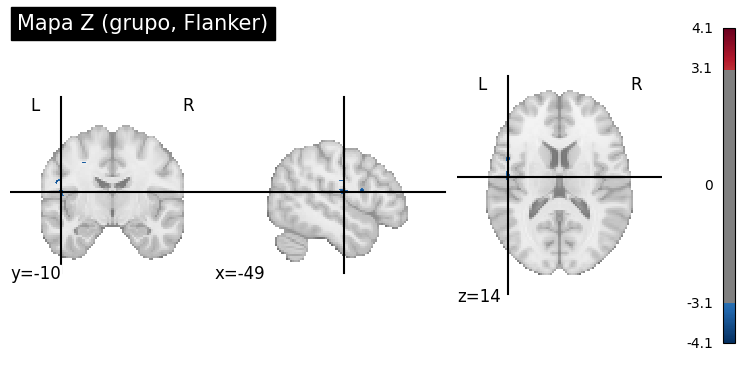

In [15]:
from nilearn import plotting

plotting.plot_stat_map(
    "C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker/group_z_map.nii.gz",
    display_mode="ortho",
    threshold=3.1,
    colorbar=True,
    title="Mapa Z (grupo, Flanker)"
)
plotting.show()


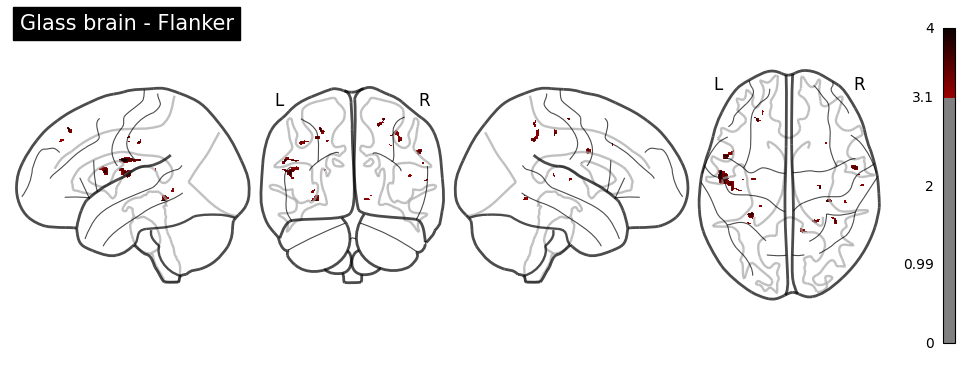

In [16]:
plotting.plot_glass_brain(
    "C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker/group_z_map.nii.gz",
    threshold=3.1,
    colorbar=True,
    display_mode="lyrz",  # lateral, sagital, axial, coronal
    title="Glass brain - Flanker"
)
plotting.show()


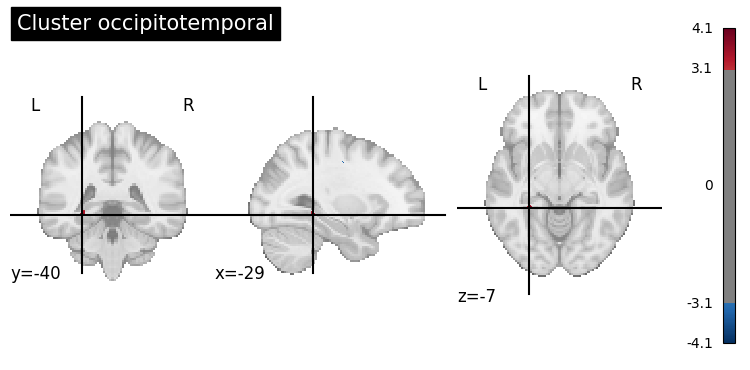

In [17]:
plotting.plot_stat_map(
    "C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker/group_z_map.nii.gz",
    cut_coords=[-29, -40, -7],
    threshold=3.1,
    title="Cluster occipitotemporal"
)
plotting.show()


In [18]:
display = plotting.plot_stat_map(
    "C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker/group_z_map.nii.gz",
    threshold=3.1,
    title="Mapa Z"
)
display.savefig("C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker/group_z_map_display.png")
display.close()


In [19]:
from nilearn import plotting

# Ruta de tu mapa Z grupal
z_map_path = "C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker/group_z_map.nii.gz"

# Carpeta de salida
out_dir = "C:/Users/Jewel/Desktop/Desktop TFM/resultados_flanker/"

print("Generando imágenes de activación...")

# 1. Vista ortogonal estándar
display1 = plotting.plot_stat_map(
    z_map_path,
    display_mode="ortho",
    threshold=3.1,
    colorbar=True,
    title="Mapa Z (Grupo - Flanker)"
)
display1.savefig(out_dir + "img_group_zmap_ortho.png")
display1.close()

# 2. Glass brain
display2 = plotting.plot_glass_brain(
    z_map_path,
    threshold=3.1,
    colorbar=True,
    display_mode="lyrz",  # lateral, sagital, axial, coronal
    title="Glass Brain (Grupo - Flanker)"
)
display2.savefig(out_dir + "img_group_zmap_glass.png")
display2.close()

# 3. Zoom en cluster significativo (-29, -40, -7)
coords = [-29, -40, -7]
display3 = plotting.plot_stat_map(
    z_map_path,
    cut_coords=coords,
    threshold=3.1,
    colorbar=True,
    title=f"Cluster en {coords}"
)
display3.savefig(out_dir + "img_group_zmap_cluster.png")
display3.close()

print("✅ Imágenes guardadas en tu carpeta de resultados:")
print("- img_group_zmap_ortho.png")
print("- img_group_zmap_glass.png")
print("- img_group_zmap_cluster.png")


Generando imágenes de activación...
✅ Imágenes guardadas en tu carpeta de resultados:
- img_group_zmap_ortho.png
- img_group_zmap_glass.png
- img_group_zmap_cluster.png
